# Base de dades 2018

Aquest notebook utilitza els conjunts de dades del 2018 proporcionats per la competició IPIN. Amb aquests s'ha seguit els següents passos:

1. Anàlisi exploratòria i reducció manual de la dimensionalitat
2. Experiments amb models d'aprenentatge automàtic

In [2]:
# llibreries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [ ]:
# Detectar si s'executa a Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# A Colab cal clonar el repositori públic per tenir accés a les dades.
# En local s'assumeix que el notebook s'executa des de l'arrel del repositori clonat.
if IN_COLAB:
    if not os.path.isdir('indoor-location'):
        !git clone https://github.com/nuriacanals3/indoor-location.git
    os.chdir('indoor-location')

In [10]:
# Carregar les dades

# Definir la ruta base de les dades
base_path = './Dades/2018/'

# Train
df_train_rss_2018 = pd.read_csv(os.path.join(base_path, 'ipin2018b_trainrss.csv'), header=None)
df_train_fl_2018  = pd.read_csv(os.path.join(base_path, 'ipin2018b_trainflr.csv'), header=None)

# Validate
df_val_rss_2018 = pd.read_csv(os.path.join(base_path, 'ipin2018b_validrss.csv'), header=None)
df_val_fl_2018  = pd.read_csv(os.path.join(base_path, 'ipin2018b_validflr.csv'), header=None)

# Test
df_test_rss_2018 = pd.read_csv(os.path.join(base_path, 'ipin2018b_ctestreducedrss.csv'), header=None)
df_test_fl_2018  = pd.read_csv(os.path.join(base_path, 'ipin2018b_ctestreducedfloor.csv'), header=None)

## Anàlisi exploratòria i reducció manual de la dimensionalitat
A continuació es fa un anàlisi de les dades i una reducció manual de la dimensionalitat del conjunt d'entrenament utilitzant els següents dataframes:
*   df_train_rss_2018
*   df_train_fl_2018



In [ ]:
# Dimensionalitat de les dades
df_train_rss_2018.shape

(1641, 844)

In [ ]:
# Anomenar columnes APs
nous_noms = [f"AP_{i}" for i in range(844)]
df_train_rss_2018.columns = nous_noms
df_val_rss_2018.columns = nous_noms
df_test_rss_2018.columns = nous_noms

# Juntar el dataset de potències amb el de planta
df_train_2018 = pd.concat([df_train_rss_2018, df_train_fl_2018], axis=1)

# Reanomenar la columna objectiu
df_train_2018 = df_train_2018.rename(columns={0: 'Pis'})

df_train_2018.head()

,AP_0,AP_1,AP_2,AP_3,AP_4,AP_5,AP_6,AP_7,AP_8,AP_9,...,AP_835,AP_836,AP_837,AP_838,AP_839,AP_840,AP_841,AP_842,AP_843,Pis
0,-69,-77,-84,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,1
1,-69,-72,-85,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,1
2,-69,-75,-85,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,1
3,-69,-70,-85,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,1
4,-70,-74,-85,-83,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,1


In [ ]:
# Canviar els valors 100 per a NaN per analitzar les dades
df_train_2018 = df_train_2018.replace(100, np.nan)

In [ ]:
# Rang potències
rss_min_global = df_train_2018.drop(columns=['Pis']).min().min()
rss_max_global = df_train_2018.drop(columns=['Pis']).max().max()

print(f"Senyal més feble global: {rss_min_global} dBm")
print(f"Senyal més forta global: {rss_max_global} dBm")

Senyal més feble global: -99.0 dBm
Senyal més forta global: -33.0 dBm


### Pas 1 - Reducció de la dimensionalitat:

Eliminar els punts d'accés (AP) que no reben cap senyal. En aquest cas s'ha passat d'un conjunt amb 844 punts d'accés a un reduït de 743.

In [ ]:
# Eliminar les columnes on tots els valors siguin NaN
df_train_2018_reduced = df_train_2018.dropna(axis=1, how='all')

print(f"Columnes originals: {df_train_2018.shape[1]}")
print(f"Columnes útils: {df_train_2018_reduced.shape[1]}")

Columnes originals: 845
Columnes útils: 744


### Pas 2 - Reducció de la dimensionalitat:

1. Anàlisi dels punts d'accés (APs) amb molt baixa latència.
2. Anàlisi de la freqüència d'aparició dels punts d'accés per planta.
3. Anàlisi de la freqüència de les potències més fortes.
4. Eliminar els APs amb una detecció menor al 5% de registres i un RSS major a -80.


**1. Anàlisi dels APs amb molt baixa latència:**

In [ ]:
# Comptar quants cops apareix NaN a cada columna
aps = df_train_2018_reduced.drop(columns=['Pis'])
comptador_no_senyal = aps.isna().sum() # Índex = nom columna (AP), Valor = comptador

# Calcular el percentatge d'absència de senyal
percentatge_no_senyal = (comptador_no_senyal / len(aps)) * 100

# Unir les dades per visualitzar-les
df_analisi_buits = pd.DataFrame({
    'Num_No_Senyal': comptador_no_senyal,
    'Percentatge_Buits': percentatge_no_senyal
})

# Ordenar descendentment per percentatge de buits
df_analisi_buits = df_analisi_buits.sort_values(by='Percentatge_Buits', ascending=False)

# Mostrar els 20 primers
print("Top 20 punts d'accés Wi-Fi menys utilitzats:")
print(df_analisi_buits.head(20))

Top 20 punts d'accés Wi-Fi menys utilitzats:
        Num_No_Senyal  Percentatge_Buits
AP_664           1640          99.939062
AP_540           1639          99.878123
AP_546           1639          99.878123
AP_545           1639          99.878123
AP_539           1639          99.878123
AP_552           1639          99.878123
AP_469           1639          99.878123
AP_470           1639          99.878123
AP_475           1639          99.878123
AP_485           1639          99.878123
AP_530           1639          99.878123
AP_507           1639          99.878123
AP_520           1639          99.878123
AP_459           1639          99.878123
AP_451           1639          99.878123
AP_363           1639          99.878123
AP_655           1639          99.878123
AP_641           1639          99.878123
AP_105           1639          99.878123
AP_656           1639          99.878123


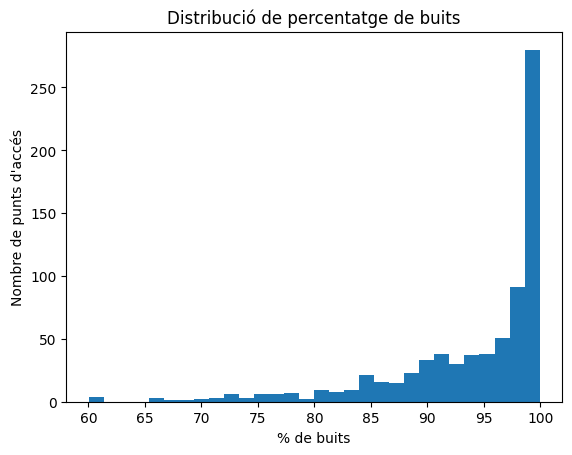

In [ ]:
# Histograma per veure la distribució global
plt.figure()
plt.hist(df_analisi_buits['Percentatge_Buits'], bins=30)
plt.xlabel("% de buits")
plt.ylabel("Nombre de punts d'accés")
plt.title("Distribució de percentatge de buits")
plt.show()


In [ ]:
# Mostrar el total que passen el 95% de buits
punts_mes_95 = df_analisi_buits[df_analisi_buits['Percentatge_Buits'] > 95]
print(f"Punts Wi-Fi amb més del 95% buits: {len(punts_mes_95)} de {aps.shape[1]}")
print(punts_mes_95)

Punts Wi-Fi amb més del 95% buits: 449 de 743
        Num_No_Senyal  Percentatge_Buits
AP_664           1640          99.939062
AP_540           1639          99.878123
AP_546           1639          99.878123
AP_545           1639          99.878123
AP_539           1639          99.878123
...               ...                ...
AP_232           1561          95.124924
AP_331           1561          95.124924
AP_70            1561          95.124924
AP_124           1559          95.003047
AP_129           1559          95.003047

[449 rows x 2 columns]


Aquest anàlisi mostra que existeixen molts punts d'accés on pràcticament tots els seus registres són buits. A continuació s'analitza en profunditat la freqüència de detecció de cada punt d'accés i la potència màxima.

**2. Anàlisi de la freqüència d'aparició dels APs en cada planta:**

Heatmap per veure quantes vegades es detecta cada AP en cada planta.

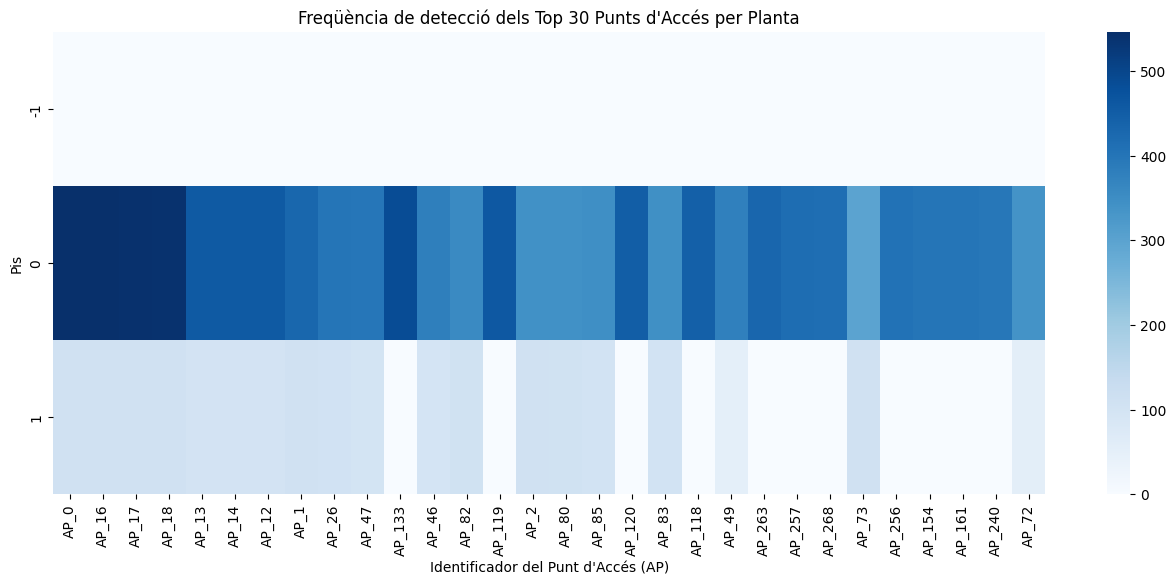

In [ ]:
# Calcular la freqüència: quantes vegades es veu cada AP a cada pis
freq_ap_pis = df_train_2018_reduced.groupby('Pis').count()

# Visualització: filtrar els 30 que més apareixen per veure-ho més clar
top_30_aps = freq_ap_pis.sum().nlargest(30).index

plt.figure(figsize=(16, 6))
sns.heatmap(freq_ap_pis[top_30_aps], cmap='Blues', annot=False)
plt.title('Freqüència de detecció dels Top 30 Punts d\'Accés per Planta')
plt.ylabel('Pis')
plt.xlabel('Identificador del Punt d\'Accés (AP)')
plt.show()



*   **Planta 0:** Gairebé tots els Top 30 APs es detecten amb una freqüència molt alta (> 400 vegades). És molt probable que la majoria de la infraestructura Wi-Fi estigui instal·lada en aquesta planta.
*   **Planta 1:** Els mateixos APs es detecten a la planta 1, però amb molta menys freqüència. Això vol dir que el senyal travessa el sostre, però el model ha de ser capaç de diferenciar si estas a la planta 0 o a la 1 basant-se en la potència.
*   **Planta -1:** És pràcticament blanca. No veu cap dels APs principals.


**3. Anàlisi de la freqüència de les potències més fortes:**

Histograma de freqüències dels valors més potents de cada registre de manera global i per planta.

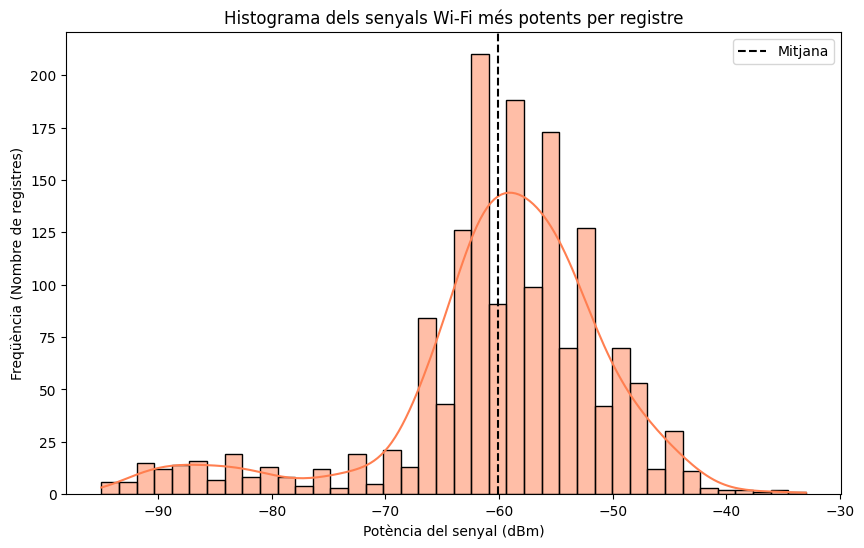

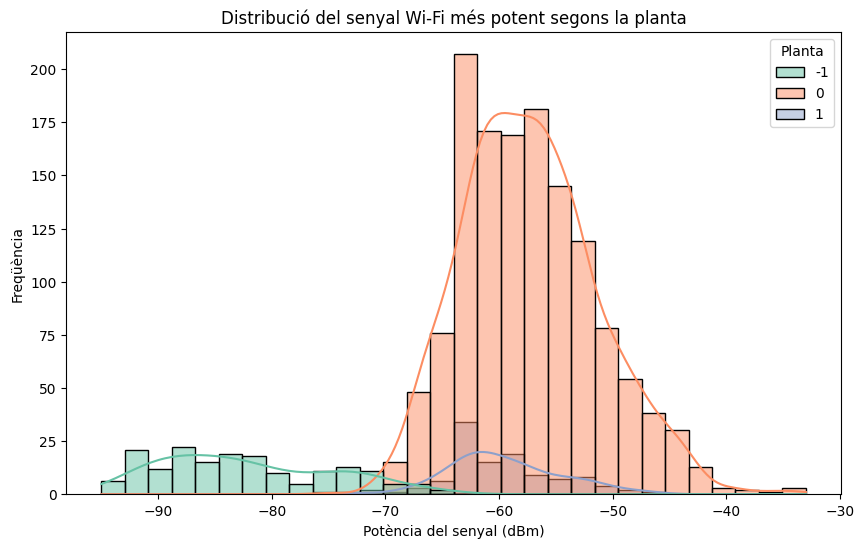

In [ ]:
# Separar la columna objectiu
pisos = df_train_2018_reduced.iloc[:, -1]
senyals = df_train_2018_reduced.iloc[:, :-1]

# Trobar el senyal més potent per a cada registre
valors_mes_potents = senyals.max(axis=1)

# Histograma global
plt.figure(figsize=(10, 6))
sns.histplot(valors_mes_potents, bins=40, color='coral', kde=True)
plt.title('Histograma dels senyals Wi-Fi més potents per registre')
plt.xlabel('Potència del senyal (dBm)')
plt.ylabel('Freqüència (Nombre de registres)')
plt.axvline(valors_mes_potents.mean(), color='black', linestyle='dashed', linewidth=1.5, label='Mitjana')
plt.legend()
plt.show()

# Histograma per pis
df_plot = senyals.copy()
df_plot['Planta'] = pisos
df_plot['max_signal'] = valors_mes_potents

plt.figure(figsize=(10, 6))
sns.histplot(data=df_plot, x='max_signal', hue='Planta', kde=True, bins=30, palette='Set2')
plt.title('Distribució del senyal Wi-Fi més potent segons la planta')
plt.xlabel('Potència del senyal (dBm)')
plt.ylabel('Freqüència')
plt.show()



*   **Planta 0:** La gran majoria de les dades provenen d'aquesta planta, mostrant un desequilibri de dades entre classes. El senyal més potent sol estar entre -65 dBm i -45 dBm, fent així, que sigui una cobertura molt bona i estable.
*   **Planta -1:** El senyal més potent que rep un dispositiu és molt dèbil (entre -95 dBm i -75 dBm). Això confirma el que apareix en el heatmap, a la planta -1 gairebé no hi arriba el senyal, i el poc que arriba és amb molt poca potència.
*   **Planta 1:** La corba blava/lila és molt petita, la qual cosa ens indica que hi ha moltes menys mostres preses en aquesta planta en comparació amb la planta 0. Tot i això, la potència màxima ronda els -65 dBm, és a dir, una bona cobertura.


**4. Eliminar els APs amb una detecció menor al 5% de registres i un RSS major a -80:**

In [ ]:
# Separar variable objectiu
aps = df_train_2018_reduced.iloc[:, :-1]
planta = df_train_2018_reduced.iloc[:, -1]

# Calcular els APs possibles a eliminar
stats_signal = pd.DataFrame({
    "count": aps.count(),
    "max": aps.max()
})

# Llindars
perc_detectats = 0.05
potencia_max = -80

# Identificar els APs a eliminar
aps_eliminar = stats_signal[
    (stats_signal['count'] < len(aps)*perc_detectats) &
    (stats_signal['max'] < potencia_max)
]

# Eliminar i ajuntar la variable planta
aps_reduced  = aps.drop(columns=aps_eliminar.index)
df_train_2018_reduced_2 = pd.concat([aps_reduced, planta], axis=1)

print(f"{len(aps_eliminar)} APs eliminats: {aps_eliminar.index.to_list()} \n {aps_eliminar}")
print(f"Dimensions originals: {df_train_2018_reduced.shape[1]}")
print(f"Dimensions noves: {df_train_2018_reduced_2.shape[1]}")

189 APs eliminats: ['AP_27', 'AP_31', 'AP_33', 'AP_34', 'AP_59', 'AP_90', 'AP_91', 'AP_100', 'AP_105', 'AP_128', 'AP_131', 'AP_143', 'AP_145', 'AP_148', 'AP_158', 'AP_164', 'AP_166', 'AP_180', 'AP_181', 'AP_183', 'AP_185', 'AP_188', 'AP_192', 'AP_232', 'AP_312', 'AP_354', 'AP_355', 'AP_356', 'AP_363', 'AP_368', 'AP_369', 'AP_377', 'AP_378', 'AP_421', 'AP_433', 'AP_451', 'AP_454', 'AP_455', 'AP_459', 'AP_461', 'AP_464', 'AP_468', 'AP_469', 'AP_470', 'AP_471', 'AP_473', 'AP_475', 'AP_476', 'AP_477', 'AP_478', 'AP_479', 'AP_480', 'AP_481', 'AP_483', 'AP_484', 'AP_485', 'AP_486', 'AP_488', 'AP_489', 'AP_490', 'AP_491', 'AP_493', 'AP_494', 'AP_495', 'AP_496', 'AP_497', 'AP_498', 'AP_499', 'AP_500', 'AP_501', 'AP_502', 'AP_503', 'AP_504', 'AP_505', 'AP_506', 'AP_507', 'AP_509', 'AP_510', 'AP_511', 'AP_517', 'AP_518', 'AP_519', 'AP_520', 'AP_521', 'AP_522', 'AP_523', 'AP_524', 'AP_525', 'AP_526', 'AP_527', 'AP_528', 'AP_529', 'AP_530', 'AP_531', 'AP_532', 'AP_533', 'AP_537', 'AP_538', 'AP_539

En aquest pas s'ha eliminat 189 APs, passant de 743 a 554.

### Pas 3 - Reducció de la dimensionalitat:

1. Anàlisi de les correlacions entre APs.
2. Eliminar APs altament correlacionats (Redundància).

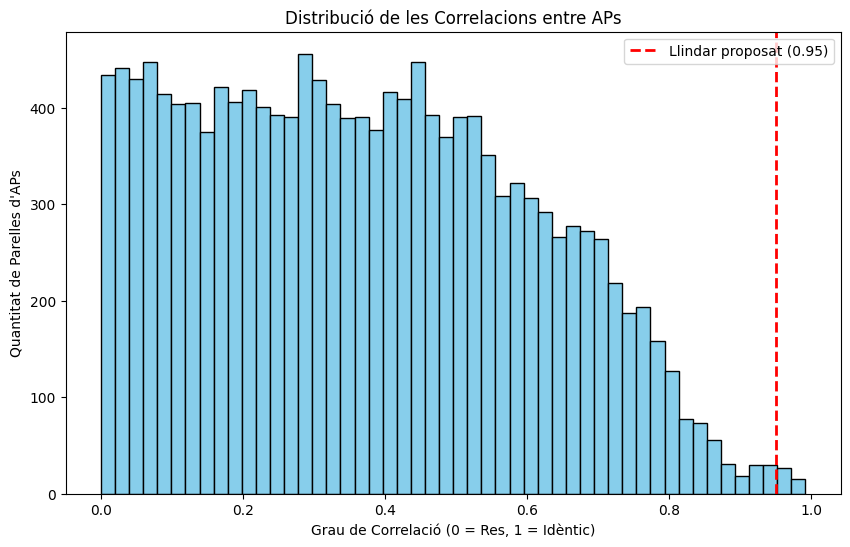

In [ ]:
# Almenys han de tenir 30 mostres compartides per calcular la correlació
minim_mostres_compartides = 30

# Calcular la matriu de correlació
corr_matrix = df_train_2018_reduced_2.drop(columns=['Pis']).corr(min_periods=minim_mostres_compartides).abs()

# Seleccionar el triangle superior de la matriu per evaluar només 1 cop cada parella
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Crear histograma
upper_values = upper.stack()
plt.figure(figsize=(10, 6))
plt.hist(upper_values, bins=50, color='skyblue', edgecolor='black')

# Dibuixar una línia vermella on llindar (0.95)
plt.axvline(x=0.95, color='red', linestyle='--', linewidth=2, label='Llindar proposat (0.95)')

plt.title('Distribució de les Correlacions entre APs')
plt.xlabel('Grau de Correlació (0 = Res, 1 = Idèntic)')
plt.ylabel('Quantitat de Parelles d\'APs')
plt.legend()
plt.show()

La majoria de punts d'accés no estan altament correlacionats, és a dir, aporten informació diferent.

In [ ]:
# Definir llindar (si dos APs s'assemble més d'aquest %, s'elimina un)
llindar = 0.95

# Identificar les columnes a eliminar
to_drop = [column for column in upper.columns if any(upper[column] > llindar)]

print(f"Amb un mínim de {minim_mostres_compartides} mostres, s'han detectat {len(to_drop)} APs altament correlacionats (llindar > {llindar})")

# Veure quins APs s'han eliminat
print("Columnes a eliminar:", to_drop)

Amb un mínim de 30 mostres, s'han detectat 35 APs altament correlacionats (llindar > 0.95)
Columnes a eliminar: ['AP_11', 'AP_13', 'AP_14', 'AP_16', 'AP_17', 'AP_18', 'AP_26', 'AP_45', 'AP_47', 'AP_55', 'AP_56', 'AP_112', 'AP_115', 'AP_119', 'AP_120', 'AP_123', 'AP_159', 'AP_160', 'AP_161', 'AP_200', 'AP_218', 'AP_219', 'AP_220', 'AP_230', 'AP_236', 'AP_242', 'AP_247', 'AP_250', 'AP_264', 'AP_276', 'AP_380', 'AP_406', 'AP_407', 'AP_410', 'AP_631']


In [ ]:
def visualitzar_totes_les_correlacions(df, matriu_upper, llindar):
    """
    Busca els parells altament correlacionats i en dibuixa un gràfic de dispersió.
    """
    # 1. Trobar quins parells superen el llindar
    parells_corr = matriu_upper.stack()
    parells_alts = parells_corr[parells_corr > llindar]

    if len(parells_alts) == 0:
        print(f"No s'ha trobat cap parell amb una correlació superior a {llindar}.")
        return

    print(f"S'han detectat {len(parells_alts)} parells altament correlacionats. Generant gràfiques...\n")
    print("-" * 50)

    # 2. Iterar sobre cada parell i dibuixar-lo
    for (ap_principal, ap_eliminat), valor in parells_alts.items():
        plt.figure(figsize=(6, 4))

        mostres_ap_princ = df[ap_principal].notna().sum()
        mostres_ap_elim = df[ap_eliminat].notna().sum()

        # Calcular quantes vegades s'han vist junts (cap dels dos és NaN)
        mostres_compartides = df[[ap_principal, ap_eliminat]].dropna().shape[0]

        # Dibuixem els punts amb certa transparència (alpha) per veure on s'acumulen
        plt.scatter(df[ap_principal], df[ap_eliminat], alpha=0.3, color='teal')

        # Estil i etiquetes
        plt.title(f"Correlació: {valor:.4f}\n{ap_principal} (Es manté) vs {ap_eliminat} (S'elimina)")
        plt.xlabel(f"Senyal de {ap_principal}")
        plt.ylabel(f"Senyal de {ap_eliminat}")
        plt.grid(True, linestyle='--', alpha=0.6)

        plt.show()


visualitzar_totes_les_correlacions(df_train_2018_reduced_2, upper, llindar)

Output hidden; open in https://colab.research.google.com to view.

En aquests gràfics, es forma una linia recta ascendent la qual mostra la correlació dels dos punts d'accés. Els dos tenen intensitats similars i creixen i decreixen en els mateixos registres.

És possible que alguns d'aquests APs siguin el mateix dispositiu físic. Avui en dia, molts dels routers generen dues o més senyals, per exemple, 5GHz i 2.4GHz.

In [ ]:
# Eliminar aquests APs redundants
df_train_2018_reduced_3 = df_train_2018_reduced_2.drop(columns=to_drop)

print(f"Dimensions originals: {df_train_2018_reduced_2.shape[1]}")
print(f"Dimensions noves: {df_train_2018_reduced_3.shape[1]}")

Dimensions originals: 555
Dimensions noves: 520


### Pas 4 - Reducció de la dimensionalitat:

1. Anàlitzar la variabilitat i potència dels punts d'accés restants.
2. Eliminar els punts d'accés amb baixa variabilitat i potència.


In [ ]:
# Analisi per AP
min_max = df_train_2018_reduced_3.drop(columns='Pis').describe().loc[['min', 'max']]

print("\nSenyal més feble i més forta per AP:")
print(min_max)


Senyal més feble i més forta per AP:
     AP_0  AP_1  AP_2  AP_3  AP_4  AP_5  AP_6  AP_7  AP_8  AP_9  ...  AP_784  \
min -91.0 -91.0 -93.0 -89.0 -91.0 -91.0 -92.0 -92.0 -93.0 -92.0  ...   -86.0   
max -54.0 -53.0 -60.0 -54.0 -59.0 -74.0 -78.0 -78.0 -74.0 -78.0  ...   -75.0   

     AP_787  AP_791  AP_792  AP_793  AP_795  AP_799  AP_800  AP_801  AP_804  
min   -87.0   -80.0   -79.0   -79.0   -85.0   -84.0   -90.0   -88.0   -91.0  
max   -79.0   -75.0   -73.0   -75.0   -77.0   -76.0   -79.0   -80.0   -77.0  

[2 rows x 519 columns]


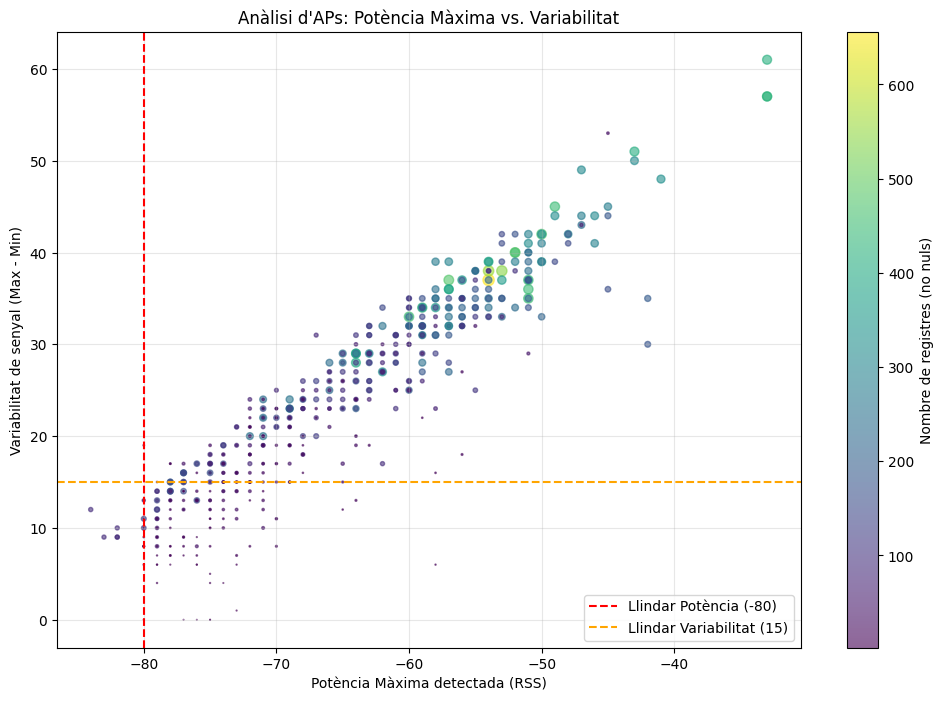

In [ ]:
# Transposar per tenir els APs a les files
df_filtre = min_max.T

# Calcular el rang (max - min)
df_filtre['rang'] = df_filtre['max'] - df_filtre['min']

# Comptar quants valors no són nulls per AP
df_filtre['comptador_non_null'] = df_train_2018_reduced_3.drop(columns='Pis').count()

# Definir els llindars
llindar_potencia_max = -80
llindar_rang = 15

# Gràfic
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df_filtre['max'],
    df_filtre['rang'],
    c=df_filtre['comptador_non_null'],
    cmap='viridis',
    alpha=0.6,
    s=df_filtre['comptador_non_null'] / 10
)

# Afegir els llindars
plt.axvline(x=llindar_potencia_max, color='red', linestyle='--', label='Llindar Potència (-80)')
plt.axhline(y=llindar_rang, color='orange', linestyle='--', label='Llindar Variabilitat (15)')

plt.colorbar(scatter, label='Nombre de registres (no nuls)')
plt.title('Anàlisi d\'APs: Potència Màxima vs. Variabilitat')
plt.xlabel('Potència Màxima detectada (RSS)')
plt.ylabel('Variabilitat de senyal (Max - Min)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


*   **Quadrant Superior Dret:** APs amb senyal fort i molta variabilitat. Són els millors predictors.

*   **Zona Esquerra:** APs que tenen una potència màxima molt baixa. Solen ser punts de plantes llunyanes o altres edificis.

*   **Zona Inferior:** APs que tenen una baixa variabilitat. Si tenen pocs registres, són prescindibles.

*   **Color/Mida:** Com més groc i gran sigui el punt, més dades té aquell AP. Si un AP està situat a la zona "dolenta" i té molt pocs registres, és prescindible.

In [ ]:
# Aplicar el filtre
aps_bons = df_filtre[
    (df_filtre['rang'] >= llindar_rang) &
    (df_filtre['max'] > llindar_potencia_max)
].index

# Crear el DataFrame filtrat
df_train_2018_reduced_4 = df_train_2018_reduced_3[aps_bons.tolist() + ['Pis']]

print(f"Dimensions originals: {df_train_2018_reduced_3.shape[1]}")
print(f"Dimensions noves: {df_train_2018_reduced_4.shape[1]}")

Dimensions originals: 520
Dimensions noves: 399


## Experiments

A continuació, s'han elaborat una sèrie d'experiments utilitzant els models Random Forest i KNN.

### Experiment 1:

Utilitzar les dades sense tractar en el RF i KNN.

In [ ]:
# Preparar les dades
X_train = df_train_rss_2018.fillna(-105)
y_train = df_train_fl_2018.values.ravel()

X_val = df_val_rss_2018.fillna(-105)
y_val = df_val_fl_2018.values.ravel()

In [ ]:
# Random Forest
# Inicialitzar el model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el model
model_rf.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_rf.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 844
Accuracy a Validació: 0.9957

Informe de Classificació:
              precision    recall  f1-score   support

          -1     1.0000    0.9355    0.9667        62
           0     0.9952    1.0000    0.9976       829
           1     1.0000    1.0000    1.0000        37

    accuracy                         0.9957       928
   macro avg     0.9984    0.9785    0.9881       928
weighted avg     0.9957    0.9957    0.9956       928



In [ ]:
# KNN
# Normalització
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Inicialitzar el model
model_knn = KNeighborsClassifier(
    n_neighbors=4,
    weights='distance',
    metric='manhattan'
)

# Entrenar el model
model_knn.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_knn.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 844
Accuracy a Validació: 0.9935

Informe de Classificació:
              precision    recall  f1-score   support

          -1     0.9516    0.9516    0.9516        62
           0     0.9964    0.9964    0.9964       829
           1     1.0000    1.0000    1.0000        37

    accuracy                         0.9935       928
   macro avg     0.9827    0.9827    0.9827       928
weighted avg     0.9935    0.9935    0.9935       928



### Experiment 2:

Anàlisi de sensibilitat dels no detectats: Test de diferents valors d'absència de valor.

In [ ]:
# Preparar les dades
X_train = df_train_rss_2018.fillna(100)
y_train = df_train_fl_2018.values.ravel()

X_val = df_val_rss_2018.fillna(100)
y_val = df_val_fl_2018.values.ravel()

In [ ]:
# Llista dels valors a provar
valors_absents = [100, -100, -105, -110, -200]

print("Resultats per a diferents valors de senyal nul:\n" + "-"*50)

for valor in valors_absents:
    # Substituïm el 100 pel nou valor
    X_train_mod = X_train.replace(100, valor)
    X_val_mod = X_val.replace(100, valor)

    # Random Forest
    model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model_rf.fit(X_train_mod, y_train)
    preds_rf = model_rf.predict(X_val_mod)
    accuracy_rf = accuracy_score(y_val, preds_rf)

    # KNN
    scaler = StandardScaler()
    X_train_mod_sc = scaler.fit_transform(X_train_mod)
    X_val_mod_sc = scaler.transform(X_val_mod)
    model_knn = KNeighborsClassifier(
      n_neighbors=4,
      weights='distance',
      metric='manhattan'
    )
    model_knn.fit(X_train_mod_sc, y_train)
    preds_knn = model_knn.predict(X_val_mod_sc)
    accuracy_knn = accuracy_score(y_val, preds_knn)

    # Resultat
    print(f"Valor absent {valor}: Accuracy RF = {accuracy_rf:.6f}")
    print(f"Valor absent {valor}: Accuracy KNN = {accuracy_knn:.6f}")

Resultats per a diferents valors de senyal nul:
--------------------------------------------------
Valor absent 100: Accuracy RF = 0.995690
Valor absent 100: Accuracy KNN = 0.993534
Valor absent -100: Accuracy RF = 0.995690
Valor absent -100: Accuracy KNN = 0.992457
Valor absent -105: Accuracy RF = 0.995690
Valor absent -105: Accuracy KNN = 0.993534
Valor absent -110: Accuracy RF = 0.995690
Valor absent -110: Accuracy KNN = 0.993534
Valor absent -200: Accuracy RF = 0.995690
Valor absent -200: Accuracy KNN = 0.992457


### Experiment 3:
Conjunt reduït amb la reducció manual inicial.

In [ ]:
# Preparar les dades
columnes_finals = df_train_2018_reduced_4.drop(columns=['Pis']).columns.tolist()

X_train = df_train_rss_2018[columnes_finals].fillna(-105)
y_train = df_train_fl_2018.values.ravel()

X_val = df_val_rss_2018[columnes_finals].fillna(-105)
y_val = df_val_fl_2018.values.ravel()

In [ ]:
# Random Forest
# Inicialitzar el model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el model
model_rf.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_rf.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 398
Accuracy a Validació: 0.9957

Informe de Classificació:
              precision    recall  f1-score   support

          -1     1.0000    0.9516    0.9752        62
           0     0.9952    1.0000    0.9976       829
           1     1.0000    0.9730    0.9863        37

    accuracy                         0.9957       928
   macro avg     0.9984    0.9749    0.9864       928
weighted avg     0.9957    0.9957    0.9956       928



In [ ]:
# KNN
# Normalització
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Inicialitzar el model
model_knn = KNeighborsClassifier(
    n_neighbors=4,
    weights='distance',
    metric='manhattan'
)

# Entrenar el model
model_knn.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_knn.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 398
Accuracy a Validació: 0.9914

Informe de Classificació:
              precision    recall  f1-score   support

          -1     0.9355    0.9355    0.9355        62
           0     0.9952    0.9964    0.9958       829
           1     1.0000    0.9730    0.9863        37

    accuracy                         0.9914       928
   macro avg     0.9769    0.9683    0.9725       928
weighted avg     0.9914    0.9914    0.9914       928



### Experiment 4:
Aplicar una reducció de dimensionalitat més agresiva.

In [ ]:
def aplicar_reduccio_agressiva(df, ap_cols, floor_col='Pis',
                               min_presencia=0.05,
                               min_variance=15.0,
                               top_n_per_floor=10,
                               quantile=0.75,
                               valor_nan=-105):
    """
    Aplica filtres de reducció de dimensionalitat per optimitzar el dataset d'APs.

    Paràmetres:
    - df: DataFrame original (NaN = AP no detectat).
    - ap_cols: Llista de columnes que són punts d'accés.
    - floor_col: Nom de la columna que indica la planta.
    - min_presencia: % mínim de registres on l'AP ha d'haver estat detectat (0.0 a 1.0).
    - min_variance: Llindar de variància.
    - top_n_per_floor: Número d'APs per cada planta.
    - quantile: Percentil per avaluar la representativitat de cada AP per planta (0.0 a 1.0).
    - valor_nan: Valor per substituir els NaN al DataFrame retornat.
    """

    print(f"--- Iniciant reducció: {len(ap_cols)} APs inicials ---")
    df_temp = df.copy()
    aps_actuals = list(ap_cols)

    # 1. FILTRE DE PRESÈNCIA
    # % de vegades que cada AP apareix
    presencia = df_temp[aps_actuals].notna().mean()
    # Aplicar filtre
    aps_actuals = presencia[presencia >= min_presencia].index.tolist()
    print(f"Pas 1 (Presència >= {min_presencia*100}%): Queden {len(aps_actuals)} APs")

    # 2. FILTRE DE VARIÀNCIA
    # Omplir NaN amb valor_nan per poder calcular la variància
    df_filled = df_temp[aps_actuals].fillna(valor_nan)
    # Elimina els AP amb poca variabilitat
    selector = VarianceThreshold(threshold=min_variance)
    selector.fit(df_filled)
    aps_actuals = [ap for ap, support in zip(aps_actuals, selector.get_support()) if support]
    print(f"Pas 2 (Variància >= {min_variance}): Queden {len(aps_actuals)} APs")

    # 3. FILTRE DE COBERTURA DE PLANTA
    millors_aps_per_planta = set()
    for planta in df_temp[floor_col].unique():
      # Agafar les dades de la planta
      df_planta = df_temp[df_temp[floor_col] == planta][aps_actuals]
      # Calcular el percentil per trobar les deteccions representatives
      representativitat = df_planta.quantile(quantile)
      # Eliminar APs que mai detectats en la planta
      representativitat = representativitat.dropna()
      # Agafar els més representatius
      n = min(top_n_per_floor, len(representativitat))
      top_aps = representativitat.nlargest(n).index.tolist()
      # Combinar els millors APs de les plantes
      millors_aps_per_planta.update(top_aps)

    aps_finals = list(millors_aps_per_planta)
    print(f"Pas 3 (Top {top_n_per_floor} APs per planta, percentil {quantile}): Queden {len(aps_finals)} APs totals")

    # Retornar el DataFrame amb les columnes seleccionades + llista dels APs seleccionats
    cols_no_ap = [c for c in df.columns if c not in ap_cols]
    df_resultat = df[cols_no_ap + aps_finals].copy()
    df_resultat[aps_finals] = df_resultat[aps_finals].fillna(valor_nan)

    return df_resultat, aps_finals

#### Experiment 4.1:

Reducció Moderada

In [ ]:
# Preparació de les dades
df_cons, aps_cons = aplicar_reduccio_agressiva(df_train_2018_reduced_4,
                                               df_train_2018_reduced_4.drop(columns=['Pis']).columns.tolist(),
                                               min_presencia=0.05,
                                               min_variance=15,
                                               top_n_per_floor=50)

X_train = df_train_rss_2018[aps_cons].fillna(-105)
y_train = df_train_fl_2018.values.ravel()

X_val = df_val_rss_2018[aps_cons].fillna(-105)
y_val = df_val_fl_2018.values.ravel()

--- Iniciant reducció: 398 APs inicials ---
Pas 1 (Presència >= 5.0%): Queden 243 APs
Pas 2 (Variància >= 15): Queden 243 APs
Pas 3 (Top 50 APs per planta, percentil 0.75): Queden 113 APs totals


In [ ]:
# Random Forest
# Inicialitzar el model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el model
model_rf.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_rf.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 113
Accuracy a Validació: 0.9946

Informe de Classificació:
              precision    recall  f1-score   support

          -1     1.0000    0.9355    0.9667        62
           0     0.9940    1.0000    0.9970       829
           1     1.0000    0.9730    0.9863        37

    accuracy                         0.9946       928
   macro avg     0.9980    0.9695    0.9833       928
weighted avg     0.9946    0.9946    0.9945       928



In [ ]:
# KNN
# Normalització
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Inicialitzar el model
model_knn = KNeighborsClassifier(
    n_neighbors=4,
    weights='distance',
    metric='manhattan'
)

# Entrenar el model
model_knn.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_knn.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 113
Accuracy a Validació: 0.9925

Informe de Classificació:
              precision    recall  f1-score   support

          -1     1.0000    0.9032    0.9492        62
           0     0.9916    1.0000    0.9958       829
           1     1.0000    0.9730    0.9863        37

    accuracy                         0.9925       928
   macro avg     0.9972    0.9587    0.9771       928
weighted avg     0.9925    0.9925    0.9923       928



#### Experiment 4.2:

Reducció Agresiva

In [ ]:
# Preparació de les dades
df_cons, aps_cons = aplicar_reduccio_agressiva(df_train_2018_reduced_4,
                                               df_train_2018_reduced_4.drop(columns=['Pis']).columns.tolist(),
                                               min_presencia=0.15,
                                               min_variance=15,
                                               top_n_per_floor=15)

X_train = df_train_rss_2018[aps_cons].fillna(-105)
y_train = df_train_fl_2018.values.ravel()

X_val = df_val_rss_2018[aps_cons].fillna(-105)
y_val = df_val_fl_2018.values.ravel()

--- Iniciant reducció: 398 APs inicials ---
Pas 1 (Presència >= 15.0%): Queden 64 APs
Pas 2 (Variància >= 15): Queden 64 APs
Pas 3 (Top 15 APs per planta, percentil 0.75): Queden 31 APs totals


In [ ]:
# Random Forest
# Inicialitzar el model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el model
model_rf.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_rf.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 31
Accuracy a Validació: 0.9731

Informe de Classificació:
              precision    recall  f1-score   support

          -1     0.7887    0.9032    0.8421        62
           0     0.9879    0.9819    0.9849       829
           1     1.0000    0.8919    0.9429        37

    accuracy                         0.9731       928
   macro avg     0.9255    0.9257    0.9233       928
weighted avg     0.9750    0.9731    0.9737       928



In [ ]:
# KNN
# Normalització
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Inicialitzar el model
model_knn = KNeighborsClassifier(
    n_neighbors=4,
    weights='distance',
    metric='manhattan'
)

# Entrenar el model
model_knn.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_knn.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 31
Accuracy a Validació: 0.9170

Informe de Classificació:
              precision    recall  f1-score   support

          -1     0.4211    0.1290    0.1975        62
           0     0.9352    0.9747    0.9545       829
           1     0.7778    0.9459    0.8537        37

    accuracy                         0.9170       928
   macro avg     0.7113    0.6832    0.6686       928
weighted avg     0.8946    0.9170    0.8999       928



### Experiment 5:

A partir del Random Forest del primer experiment, analitzar els punts d'accés més importants que el model determina.

El RF té la propietat feature_importances_ que diu quins APs considera que són més importants.

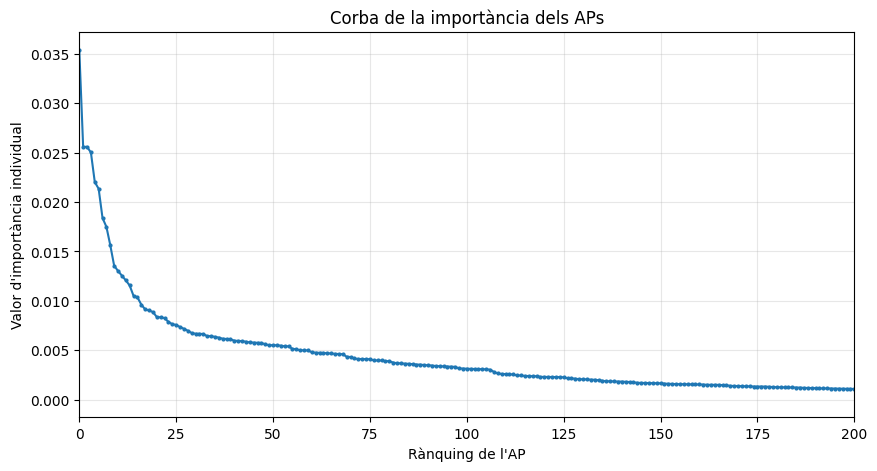

In [ ]:
# APs més importants
importances = model_rf.feature_importances_
noms_columnes = X_train.columns

# Crear un rànquing
importances_df = pd.DataFrame({'AP': noms_columnes, 'Importancia': importances})
data_sorted = importances_df.sort_values(by='Importancia', ascending=False)

# Visualitzar
plt.figure(figsize=(10, 5))
plt.plot(data_sorted['Importancia'].values, marker='o', markersize=2, linestyle='-')
plt.title('Corba de la importància dels APs')
plt.xlabel('Rànquing de l\'AP')
plt.ylabel('Valor d\'importància individual')
plt.grid(True, alpha=0.3)
plt.xlim(0, 200)
plt.show()

In [ ]:
# Preparació de les dades amb els millors APs trobats per RF
n_aps = 100
millors_aps = data_sorted.head(n_aps)['AP'].tolist()
X_train_top = X_train[millors_aps]
X_val_top = X_val[millors_aps]

In [ ]:
# Random Forest
model_rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf_final.fit(X_train_top, y_train)

# Validar
preds = model_rf_final.predict(X_val_top)

# Avaluació resultats
print(f"Nombre d'APs utilitzats: {len(X_train_top.columns)}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds, digits=4))

Nombre d'APs utilitzats: 100
Accuracy a Validació: 0.9968

Informe de Classificació:
              precision    recall  f1-score   support

          -1     1.0000    0.9516    0.9752        62
           0     0.9964    1.0000    0.9982       829
           1     1.0000    1.0000    1.0000        37

    accuracy                         0.9968       928
   macro avg     0.9988    0.9839    0.9911       928
weighted avg     0.9968    0.9968    0.9967       928



### Avaluació final

Utilitzant el Random Forest de l'experiment 5 amb 100 APs.

In [ ]:
# Preparació de les dades
X_test = df_test_rss_2018[millors_aps].fillna(-105)
y_test = df_test_fl_2018.values

preds_test = model_rf_final.predict(X_test)
print(f"Accuracy a Test: {accuracy_score(y_test, preds_test):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_test, preds_test, digits=4))

Accuracy a Test: 0.9697

Informe de Classificació:
              precision    recall  f1-score   support

          -1     1.0000    0.7273    0.8421        11
           0     0.9647    1.0000    0.9820        82
           1     1.0000    1.0000    1.0000         6

    accuracy                         0.9697        99
   macro avg     0.9882    0.9091    0.9414        99
weighted avg     0.9708    0.9697    0.9676        99

